# 41 - Code Challenge: Regression on Wine Data

**Section:** Metaparameters | **Prereqs:** `Metaparameters/LearningRateDecay.ipynb` | **Next:** `Model Evaluation/ARPF.ipynb`

Predict residual sugar from the other 10 wine features - a **regression** task,
where every other wine notebook in this section was classification.

**What changes for regression:** one output unit, no activation on it,
`MSELoss`, float targets shaped `(N,1)`, and no accuracy. The score is correlation
between prediction and truth, or the loss itself.

**Three splits, done right.** 60% train, 20% dev, 20% test, and the
`StandardScaler` is `fit` on train only and then `transform`-ed onto dev and
test. This is the correct pipeline - compare with the leaky versions earlier in
the course.

**Everything from this section, applied at once:** standardised inputs, batch
norm after every layer, mini-batches, a dev split for monitoring.

**The honest finding** is in the last cell. The correlation matrix shows residual
sugar is only weakly related to the other features, so no model can predict it
well. Plot your correlations *before* training - it tells you what performance is
even available, and saves you tuning a model against a problem that has no
signal.

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline

# https://archive.ics.uci.edu/

In [ ]:
!pip install ucimlrepo

In [ ]:
# Wine quality features; the quality label is not used in this notebook.
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features

cols = X.columns

In [ ]:
data = X

In [ ]:
# residual_sugar becomes the TARGET; the remaining 10 columns are the features.
y = X['residual_sugar']
X = X.drop('residual_sugar',axis=1)

<Axes: >

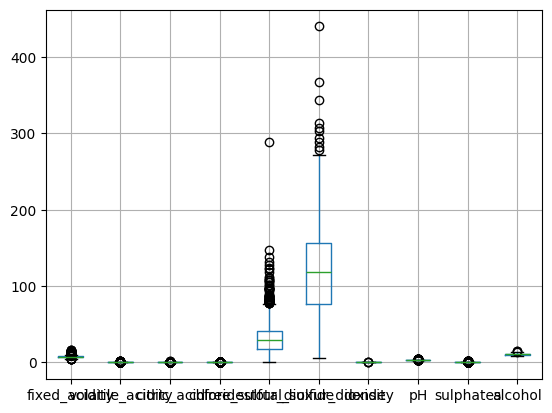

In [ ]:
# Box plot of the raw features - wildly different scales, so standardising is
# required before training.
X.boxplot()

In [ ]:
# Three-way split done properly:
#   1. 60/40, then split that 40 in half -> 60% train, 20% dev, 20% test,
#   2. scaler.fit(X_train) ONLY, then transform all three splits.
# random_state fixes the shuffle so the splits are reproducible across runs.
X = torch.tensor(X.to_numpy(),dtype=torch.float)
y = torch.tensor(y.to_numpy(),dtype=torch.float)


X_train , X_dev, Y_train, Y_dev = train_test_split(X,y,random_state=42,test_size=0.4,shuffle=True)
X_dev, X_test, Y_dev, Y_test = train_test_split(X_dev,Y_dev, random_state=42,test_size=0.5,shuffle=True)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train = torch.tensor(scaler.transform(X_train), dtype=torch.float)
X_dev = torch.tensor(scaler.transform(X_dev), dtype=torch.float)
X_test = torch.tensor(scaler.transform(X_test), dtype=torch.float)

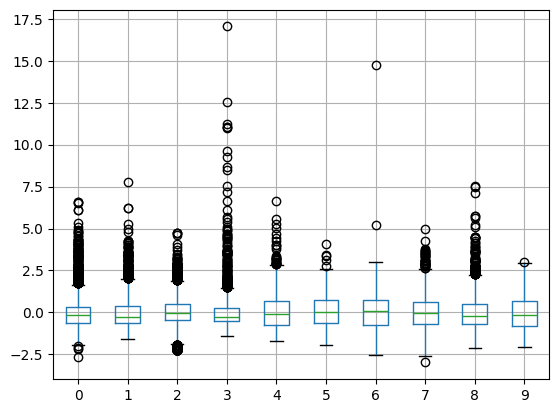

In [ ]:
# Post-scaling box plot: everything centred and comparable.
(pd.DataFrame(X_train)).boxplot();

In [ ]:
# Targets reshaped to (N,1) to match the model's output shape.
# MSELoss broadcasts silently if the shapes disagree - (N,) against (N,1)
# produces an (N,N) matrix of differences and a meaningless loss. Reshaping here
# is not cosmetic.
Y_train = Y_train.to(torch.float32).view(-1, 1)
Y_dev   = Y_dev.to(torch.float32).view(-1, 1)
Y_test  = Y_test.to(torch.float32).view(-1, 1)

dev_data = TensorDataset(X_dev,Y_dev)
train_data = TensorDataset(X_train, Y_train)
test_data = TensorDataset(X_test, Y_test)

bs = 16
train_loader = DataLoader(train_data,batch_size=bs, shuffle=True)
dev_loader = DataLoader(dev_data,batch_size=dev_data.tensors[0].shape[0])
test_loader = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])


In [ ]:
# 10 -> 128 -> 128 -> 128 -> 1 with batch norm after each Linear.
# The output layer has NO activation: a regression target can be any real value,
# and a ReLU there would clip every negative prediction to zero.
class model(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(10,128)
    self.bnorm0 = nn.BatchNorm1d(128)

    self.fc1 = nn.Linear(128,128)
    self.bnorm1 = nn.BatchNorm1d(128)

    self.fc2 = nn.Linear(128,128)
    self.bnorm2 = nn.BatchNorm1d(128)

    self.output_layer = nn.Linear(128,1)


  def forward(self,x):

    x = F.relu(self.bnorm0(self.input_layer(x)))

    x = F.relu(self.bnorm1(self.fc1(x)))

    x = F.relu(self.bnorm2(self.fc2(x)))

    return self.output_layer(x)

In [ ]:
# MSELoss for regression. Note the dev set is evaluated each epoch, but the
# test set is not touched until the end - the discipline this course has been
# building towards.
epochs = 1000
lr = 0.01

sugar = model()

lossFunc = nn.MSELoss()
optimizer = torch.optim.SGD(sugar.parameters(), lr=lr)

dev_loss = []
losses = torch.zeros(epochs)

for epoch in range(epochs):

  sugar.train()
  batch_loss = []

  for x,y in train_loader:

    yhat = sugar.forward(x)

    loss = lossFunc(yhat,y)
    batch_loss.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  losses[epoch] = np.mean(batch_loss)

  sugar.eval()
  with torch.no_grad():
    X,Y = next(iter(dev_loader))
    preds = sugar.forward(X)

    dev_loss.append(lossFunc(preds,Y))


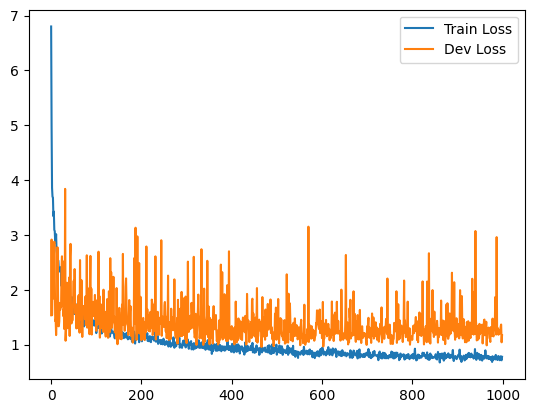

In [ ]:
# Train and dev LOSS (not accuracy - there is no accuracy in regression).
# Dev loss rising while train loss falls is the regression signature of
# overfitting.
plt.plot(losses, label = 'Train Loss')
plt.plot(dev_loss, label="Dev Loss")
plt.legend();

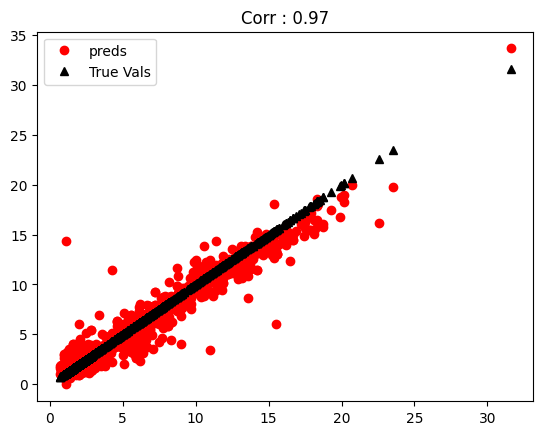

In [153]:
# Predictions against truth on the untouched test set. A perfect model puts
# every red point on the black diagonal. The correlation in the title is the
# score; expect it to be low, and see the next cell for why.
# Test Data
a,b = next(iter(test_loader))
preds = sugar.forward(a)
plt.plot(b,preds.detach(), "or", label="preds")
plt.plot(b,b,"k^",label="True Vals")
plt.legend();

plt.title(f"Corr : {np.corrcoef(preds.detach().T, b.T)[0,1] :.2f}");


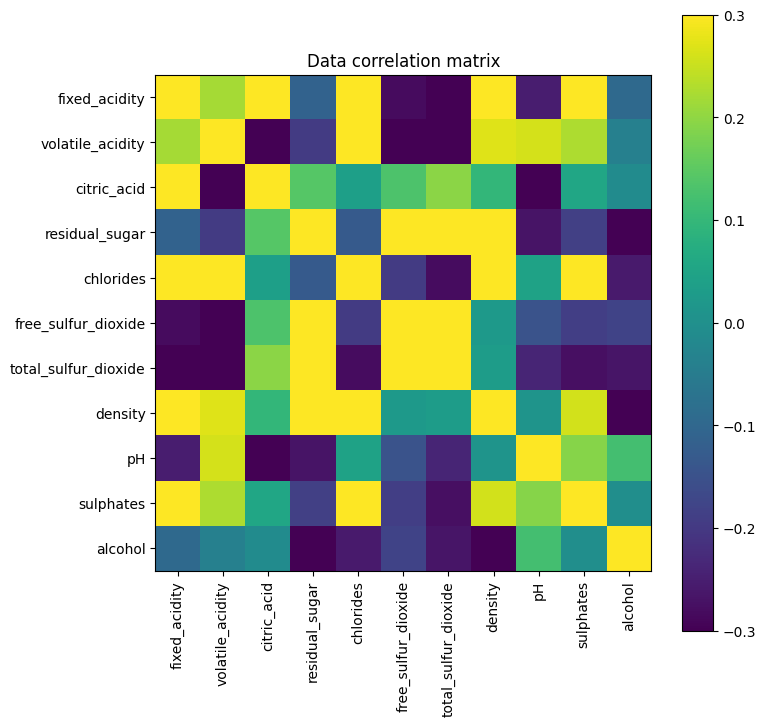

In [ ]:
# The explanation. The correlation matrix shows residual sugar is only weakly
# correlated with the other features - the information needed to predict it is
# mostly not in this dataset.
# Run this FIRST on a new regression problem. It tells you what accuracy is
# achievable before you spend an afternoon tuning a model.
fig = plt.figure(figsize=(8,8))

plt.imshow(np.corrcoef(data.T),vmin=-.3,vmax=.3)
plt.xticks(range(len(data.keys())),labels=data.keys(),rotation=90)
plt.yticks(range(len(data.keys())),labels=data.keys())
plt.colorbar()
plt.title('Data correlation matrix')
plt.show()